In [2]:
import os
from pathlib import Path

In [3]:
# 创建项目目录结构
# 获取当前脚本所在目录的绝对路径
current_dir = Path.cwd()  # 或者 Path(".").absolute()
project_root = current_dir / "ship_detection"
dataset_dir = project_root / "datasets" / "seaships"
models_dir = project_root / "models"
results_dir = project_root / "results"

print(f"项目根目录: {project_root}")

项目根目录: D:\ShipTarget\ship_detection


In [4]:
from ultralytics import YOLO
import yaml

# 加载数据集配置
with open(dataset_dir / "data.yaml", 'r') as f:
    data_config = yaml.safe_load(f)

print("数据集配置:")
print(f"类别数量: {data_config['nc']}")
print(f"类别名称: {data_config['names']}")
print(f"训练图像路径: {dataset_dir / data_config['train']}")
print(f"验证图像路径: {dataset_dir / data_config['val']}")

# 验证目录是否存在
train_img_dir = dataset_dir / data_config['train']
assert train_img_dir.exists(), f"训练图像目录不存在: {train_img_dir}"

数据集配置:
类别数量: 1
类别名称: ['ship']
训练图像路径: D:\ShipTarget\ship_detection\datasets\seaships\images\train
验证图像路径: D:\ShipTarget\ship_detection\datasets\seaships\images\val


In [5]:
# 加载预训练模型
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'  # 设置 HF 镜像
model = YOLO('yolo11s.pt')  # 将自动下载预训练权重
print("模型加载成功")

模型加载成功


In [6]:
# 开始训练
results = model.train(
    data=str(dataset_dir / "data.yaml"),  # 数据集配置
    epochs=100,                            # 训练轮数（根据开题报告）
    imgsz=512,                              # 输入图像尺寸
    batch=8,                                # 批次大小（根据显存调整）
    workers=2,                                # 数据加载线程数
    device=0,                                 # cpu
    project=str(results_dir / "yolov11"),    # 结果保存目录
    name="baseline512",                          # 实验名称
    exist_ok=True,                             # 允许覆盖
    patience=20,                                # 早停耐心值
    save=True,                                   # 保存模型
    save_period=10,                               # 每10轮保存一次
    plots=True,                                    # 生成训练图表
    cache=False,                                     # 缓存数据加速关闭，减轻压力
)

print("YOLOv11训练完成")

New https://pypi.org/project/ultralytics/8.4.34 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.16  Python-3.11.14 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\ShipTarget\ship_detection\datasets\seaships\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mo

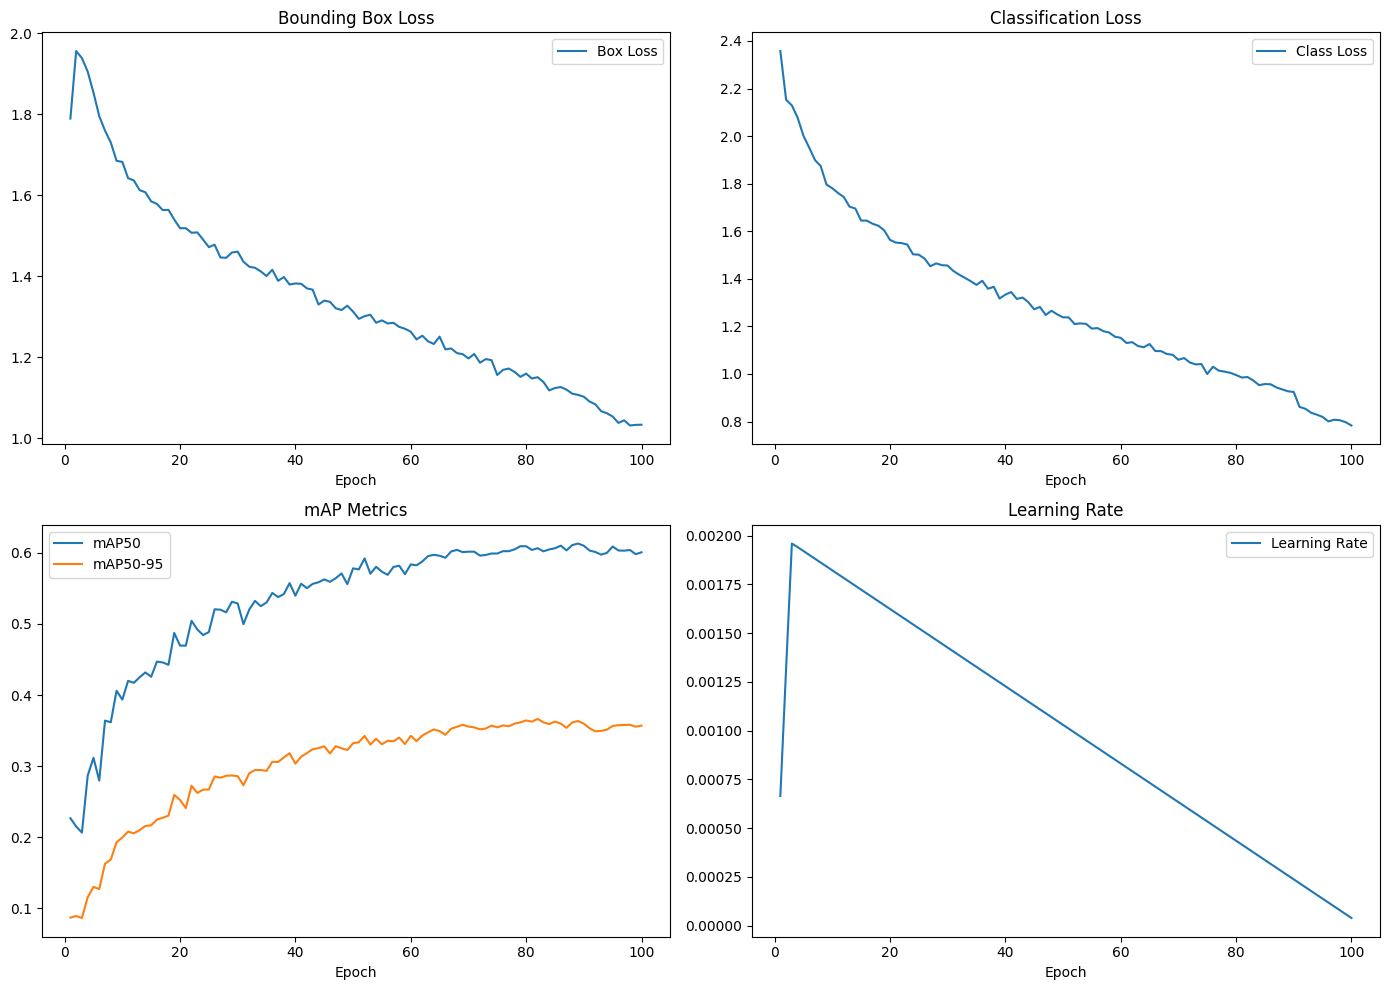

In [9]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

# 读取训练日志
results_csv = results_dir / "yolov11" / "baseline" / "results.csv"
if results_csv.exists():
    df = pd.read_csv(results_csv)
    
    # 绘制损失曲线
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    axes[0, 0].plot(df['epoch'], df['train/box_loss'], label='Box Loss')
    axes[0, 0].set_title('Bounding Box Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].legend()
    
    axes[0, 1].plot(df['epoch'], df['train/cls_loss'], label='Class Loss')
    axes[0, 1].set_title('Classification Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].legend()
    
    axes[1, 0].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50')
    axes[1, 0].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95')
    axes[1, 0].set_title('mAP Metrics')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].legend()
    
    axes[1, 1].plot(df['epoch'], df['lr/pg0'], label='Learning Rate')
    axes[1, 1].set_title('Learning Rate')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].legend()
    
    plt.tight_layout()
    plt.show()
else:
    print("等待训练生成结果文件...")

In [10]:
# 在测试集上评估模型
best_model_path = results_dir / "yolov11" / "baseline" / "weights" / "best.pt"
model = YOLO(best_model_path)

# 评估
metrics = model.val(
    data=str(dataset_dir / "data.yaml"),
    split='test',  # 使用测试集
    batch=16,
    imgsz=640,
    conf=0.25,     # 置信度阈值
    iou=0.5,       # IoU阈值
)

print("YOLOv11评估结果:")
print(f"mAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"召回率: {metrics.box.mr:.4f}")
print(f"精确率: {metrics.box.mp:.4f}")

Ultralytics 8.4.16  Python-3.11.14 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLO11s summary (fused): 101 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access  (ping: 0.10.1 ms, read: 583.1132.2 MB/s, size: 206.3 KB)
val: Scanning D:\ShipTarget\ship_detection\datasets\seaships\labels\test... 1018 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1018/1018 2.5Kit/s 0.4s<0.0s
val: New cache created: D:\ShipTarget\ship_detection\datasets\seaships\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 64/64 5.0it/s 12.9s0.2s
                   all       1018       2865      0.675      0.563      0.647      0.426
Speed: 1.2ms preprocess, 8.1ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to D:\ShipTarget\runs\detect\val
YOLOv11评估结果:
mAP50: 0.6467
mAP50-95: 0.4264
召回率: 0.5634
精确率: 0.6750



image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000121457.jpg: 448x640 4 ships, 75.7ms
Speed: 1.7ms preprocess, 75.7ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)


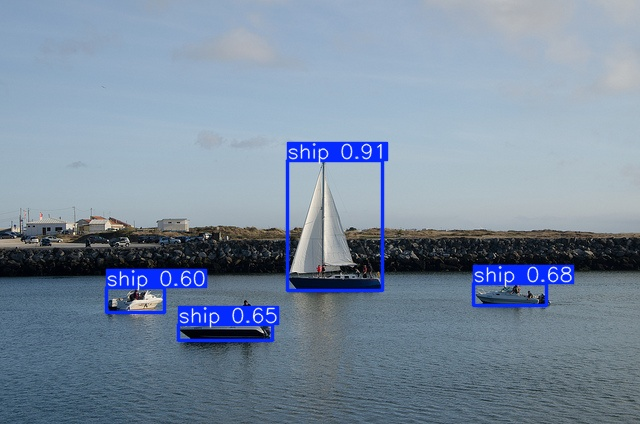


image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000250227.jpg: 448x640 2 ships, 10.9ms
Speed: 1.1ms preprocess, 10.9ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)


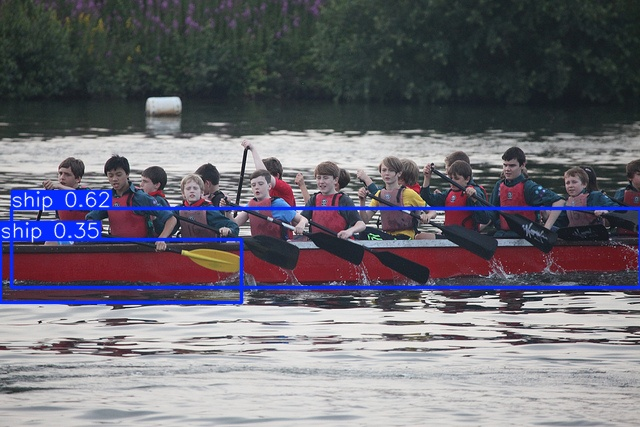


image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000121651.jpg: 480x640 8 ships, 60.6ms
Speed: 1.1ms preprocess, 60.6ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)


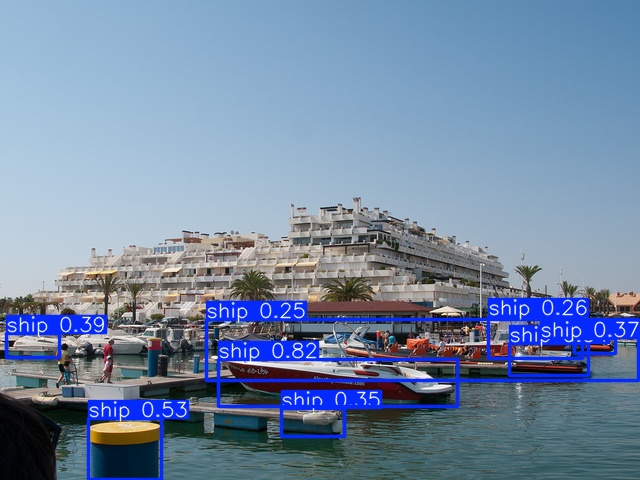


image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\002659.jpg: 384x640 4 ships, 60.0ms
Speed: 1.7ms preprocess, 60.0ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)


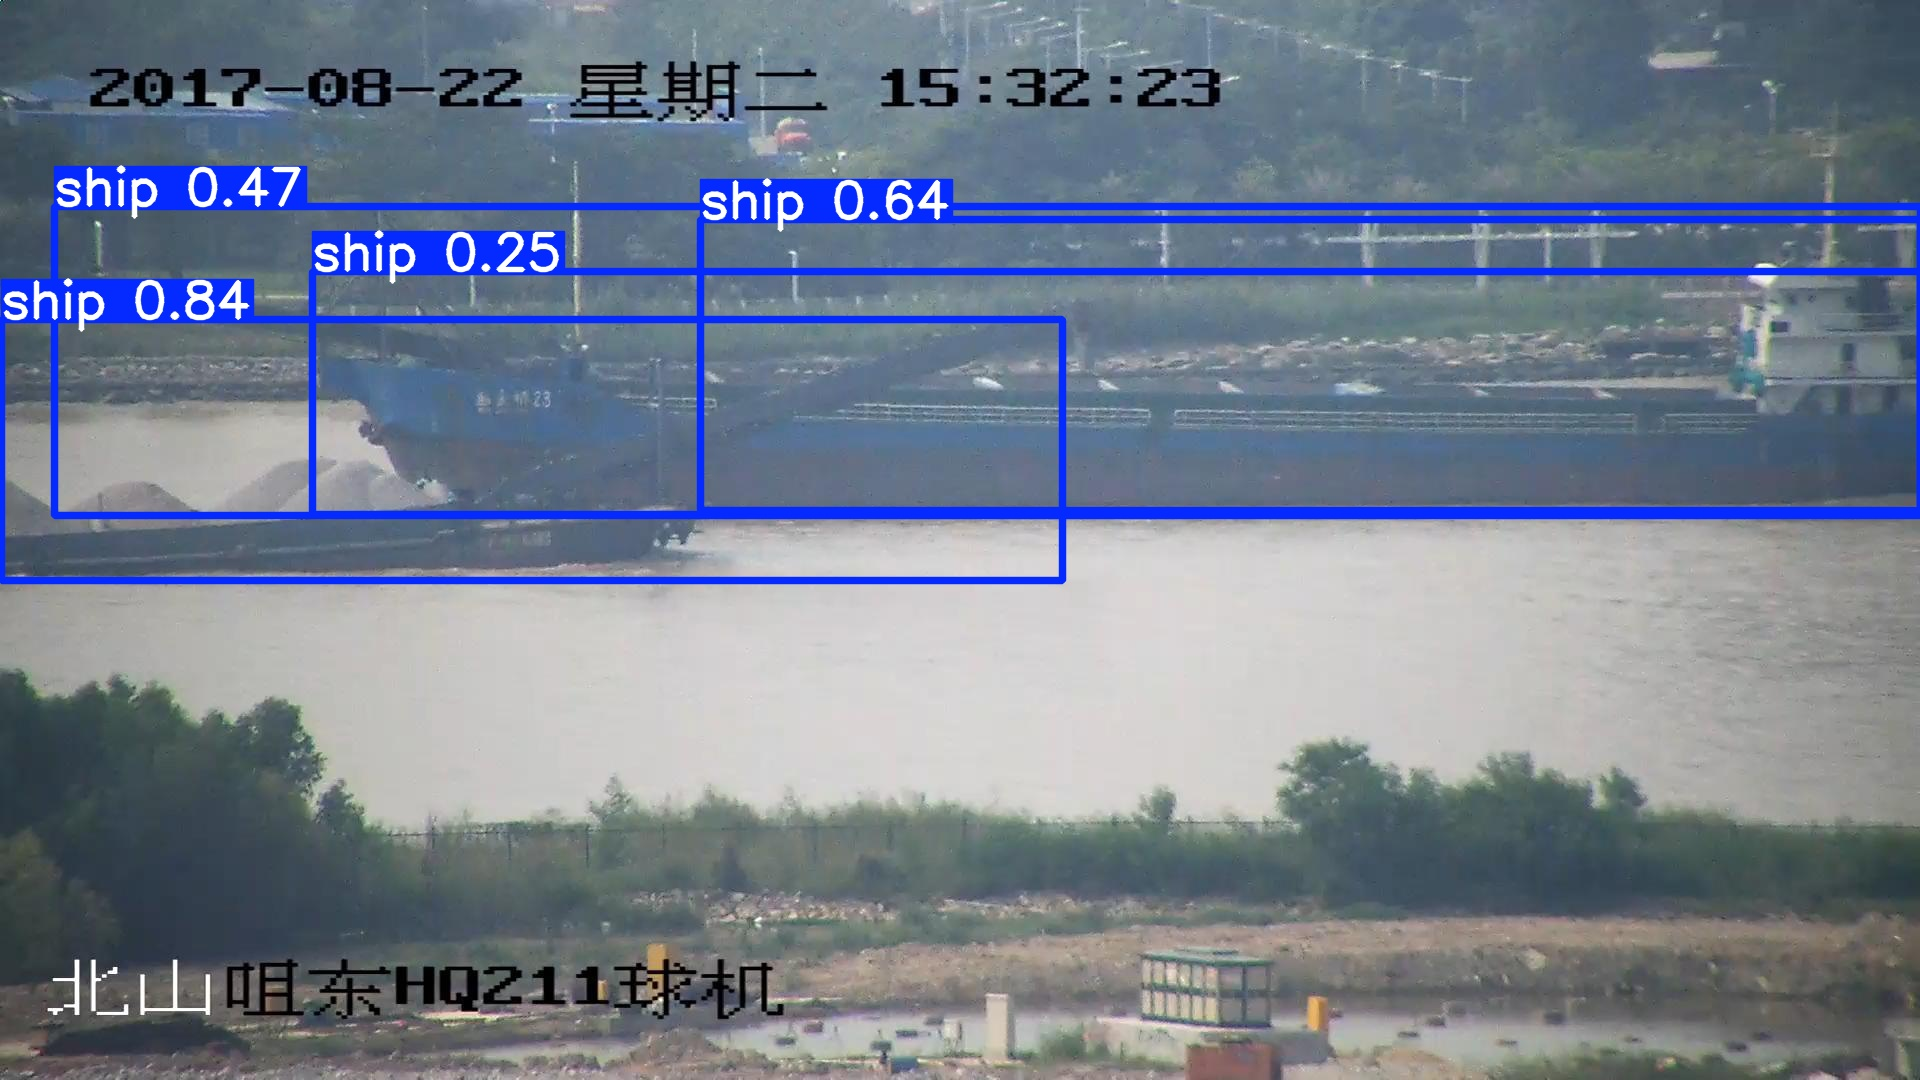

In [11]:
# 随机选取测试集图像进行推理
import random
import cv2
from IPython.display import Image, display

test_img_dir = dataset_dir / "images" / "test"
test_images = list(test_img_dir.glob("*.jpg")) + list(test_img_dir.glob("*.png"))

if test_images:
    sample_images = random.sample(test_images, min(4, len(test_images)))
    
    for img_path in sample_images:
        # 推理
        results = model(str(img_path), conf=0.25)
        
        # 保存结果
        output_path = results_dir / "yolov11" / "baseline" / f"pred_{img_path.name}"
        results[0].save(str(output_path))
        
        # 显示
        display(Image(filename=str(output_path)))


基准模型性能对比:
       Model  mAP@0.5  mAP@0.5:0.95  Recall   FPS  Params(M)
     YOLOv11   0.6467        0.4264  0.5634 123.0        9.4
Faster R-CNN   0.4820        0.2620       -  13.7       41.0


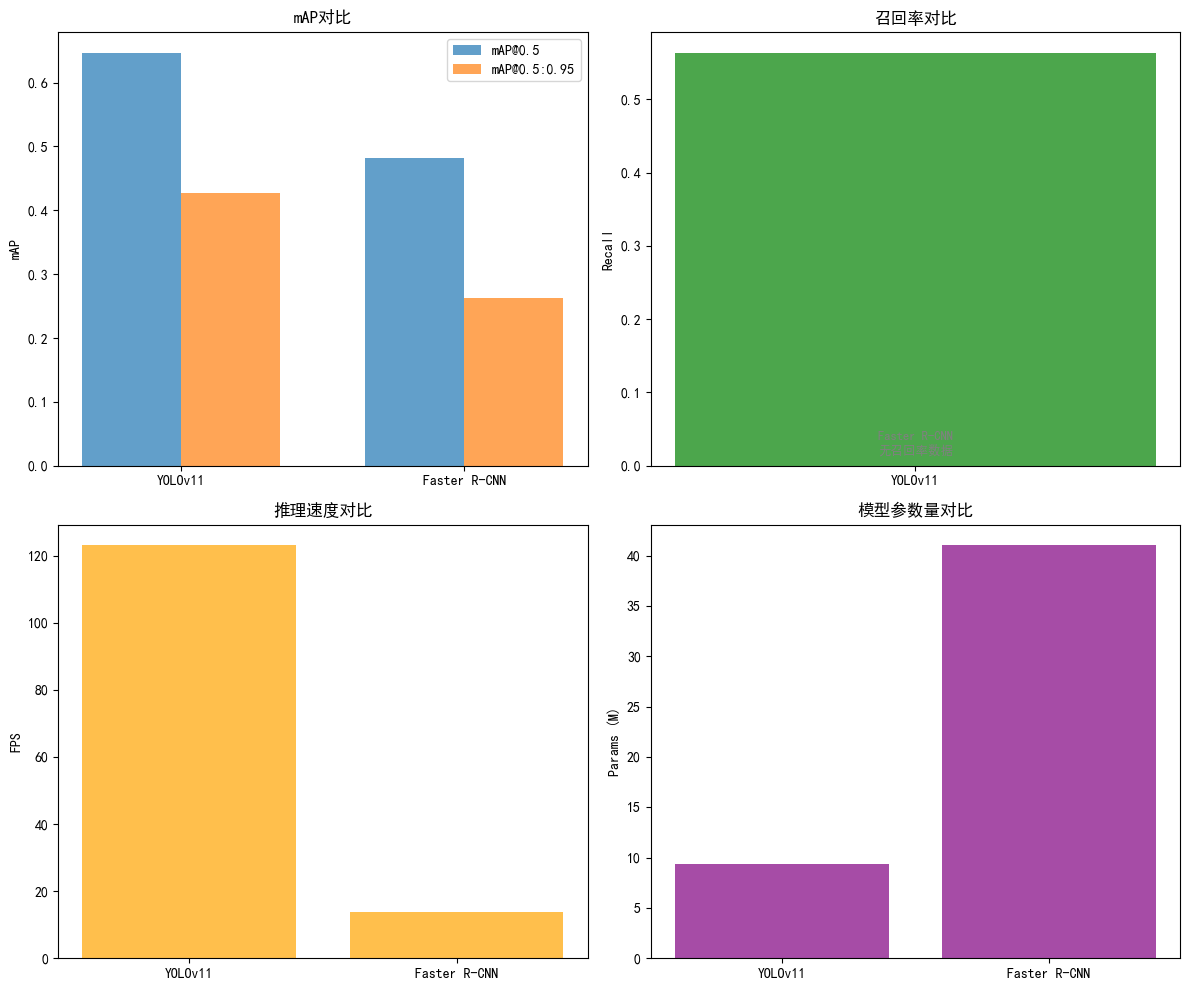

In [6]:
# 汇总两个模型的性能指标
results_summary = {
    'Model': ['YOLOv11', 'Faster R-CNN'],
    'mAP@0.5': [0.6467, 0.482],  
    'mAP@0.5:0.95': [0.4264, 0.262],
    'Recall': [0.5634, None],
    'FPS': [123, 13.7],
    'Params(M)': [9.4, 41.0]
}

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']       
plt.rcParams['axes.unicode_minus'] = False

df_results = pd.DataFrame(results_summary)
print("\n基准模型性能对比:")
print(df_results.to_string(index=False, na_rep='-'))

# 创建 2 行 2 列的子图，调整图形尺寸
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# 将 axes 展平为一维数组，方便索引
ax = axes.flatten()

# 1. mAP对比（放在第一个子图 ax[0]）
x = np.arange(len(df_results['Model']))  # [0,1]
width = 0.35
bars1 = ax[0].bar(x - width/2, df_results['mAP@0.5'], width,
                  label='mAP@0.5', alpha=0.7, color='C0')
bars2 = ax[0].bar(x + width/2, df_results['mAP@0.5:0.95'], width,
                  label='mAP@0.5:0.95', alpha=0.7, color='C1')
ax[0].set_ylabel('mAP')
ax[0].set_title('mAP对比')
ax[0].set_xticks(x)
ax[0].set_xticklabels(df_results['Model'])
ax[0].legend()

# 2. 召回率对比（第二个子图 ax[1]）
recall_data = df_results[['Model', 'Recall']].dropna()
if not recall_data.empty:
    ax[1].bar(recall_data['Model'], recall_data['Recall'],
              color='green', alpha=0.7)
ax[1].set_ylabel('Recall')
ax[1].set_title('召回率对比')
if pd.isna(df_results.loc[1, 'Recall']):
    ax[1].text(0.5, 0.02, 'Faster R-CNN\n无召回率数据',
               ha='center', va='bottom', fontsize=9, color='gray',
               transform=ax[1].transAxes)

# 3. FPS对比（第三个子图 ax[2]）
ax[2].bar(df_results['Model'], df_results['FPS'],
          color='orange', alpha=0.7)
ax[2].set_ylabel('FPS')
ax[2].set_title('推理速度对比')

# 4. 参数量对比（第四个子图 ax[3]）
ax[3].bar(df_results['Model'], df_results['Params(M)'],
          color='purple', alpha=0.7)
ax[3].set_ylabel('Params (M)')
ax[3].set_title('模型参数量对比')

plt.tight_layout()
plt.show()

In [1]:
import os
from pathlib import Path
import numpy as np
import torch
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import rcParams

# 设置中文字体（解决乱码）
plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False  # 正常显示负号

def analyze_failures(model, test_images_dir, labels_dir, conf_threshold=0.25, iou_threshold=0.5, max_images=None):
    
    test_images = sorted(Path(test_images_dir).glob('*.jpg')) + sorted(Path(test_images_dir).glob('*.png'))
    if max_images is not None:
        test_images = test_images[:max_images]  # 取前 max_images 张

    labels_dir = Path(labels_dir)
    
    tp_total = 0
    fp_total = 0
    fn_total = 0
    failures = {}
    
    for img_path in test_images:
        # 读取真实标签
        label_file = labels_dir / img_path.with_suffix('.txt').name
        gt_boxes = []
        if label_file.exists():
            with open(label_file, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        class_id = int(parts[0])
                        xc, yc, w, h = map(float, parts[1:])
                        # 转换为绝对坐标 (x1, y1, x2, y2)
                        img = cv2.imread(str(img_path))
                        img_h, img_w = img.shape[:2]
                        x1 = (xc - w/2) * img_w
                        y1 = (yc - h/2) * img_h
                        x2 = (xc + w/2) * img_w
                        y2 = (yc + h/2) * img_h
                        gt_boxes.append([x1, y1, x2, y2, class_id])
        else:
            print(f"警告: {label_file} 不存在，跳过该图像")
            continue
        
        # 模型推理
        results = model(str(img_path), conf=conf_threshold)
        pred_boxes = []
        if results[0].boxes is not None:
            for box in results[0].boxes:
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                conf = box.conf[0].item()
                class_id = int(box.cls[0].item())
                pred_boxes.append([x1, y1, x2, y2, conf, class_id])
        
        # 计算 TP, FP, FN
        pred_boxes.sort(key=lambda x: x[4], reverse=True)
        gt_matched = [False] * len(gt_boxes)
        tp = 0
        fp = 0
        
        for pred in pred_boxes:
            pred_box = pred[:4]
            best_iou = 0
            best_gt_idx = -1
            for i, gt in enumerate(gt_boxes):
                if gt_matched[i]:
                    continue
                # 计算 IoU
                xA = max(pred_box[0], gt[0])
                yA = max(pred_box[1], gt[1])
                xB = min(pred_box[2], gt[2])
                yB = min(pred_box[3], gt[3])
                interArea = max(0, xB - xA) * max(0, yB - yA)
                if interArea == 0:
                    iou = 0
                else:
                    boxAArea = (pred_box[2] - pred_box[0]) * (pred_box[3] - pred_box[1])
                    boxBArea = (gt[2] - gt[0]) * (gt[3] - gt[1])
                    iou = interArea / float(boxAArea + boxBArea - interArea)
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = i
            if best_iou >= iou_threshold:
                tp += 1
                gt_matched[best_gt_idx] = True
            else:
                fp += 1
        
        fn = len(gt_boxes) - sum(gt_matched)
        
        tp_total += tp
        fp_total += fp
        fn_total += fn
        
        # 记录该图像的失败详情
        failures[img_path.name] = {
            'tp': tp,
            'fp': fp,
            'fn': fn,
            'gt_count': len(gt_boxes),
            'pred_count': len(pred_boxes)
        }
    
    # 整体统计
    precision = tp_total / (tp_total + fp_total) if (tp_total + fp_total) > 0 else 0
    recall = tp_total / (tp_total + fn_total) if (tp_total + fn_total) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    results = {
        'total_images': len(test_images),
        'tp': tp_total,
        'fp': fp_total,
        'fn': fn_total,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'failures': failures
    }
    return results


def visualize_failures(model, failures_dict, test_images_dir, labels_dir, num_samples, conf_threshold=0.25):
    test_images_dir = Path(test_images_dir)
    labels_dir = Path(labels_dir)
    
    # 按 (fp+fn) 降序排序
    sorted_items = sorted(failures_dict.items(), key=lambda x: x[1]['fp'] + x[1]['fn'], reverse=True)
    samples = sorted_items[:num_samples]
    
    for img_name, info in samples:
        img_path = test_images_dir / img_name
        if not img_path.exists():
            print(f"图像不存在: {img_path}")
            continue
        
        # 读取图像
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_h, img_w = img.shape[:2]
        
        # 读取真实框
        label_path = labels_dir / img_path.with_suffix('.txt').name
        gt_boxes = []
        if label_path.exists():
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        xc, yc, w, h = map(float, parts[1:])
                        x1 = (xc - w/2) * img_w
                        y1 = (yc - h/2) * img_h
                        x2 = (xc + w/2) * img_w
                        y2 = (yc + h/2) * img_h
                        gt_boxes.append([x1, y1, x2, y2])
        
        # 模型预测（用于获取预测框）
        results = model(str(img_path), conf=conf_threshold)
        pred_boxes = []
        if results[0].boxes is not None:
            for box in results[0].boxes:
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                conf = box.conf[0].item()
                pred_boxes.append([x1, y1, x2, y2, conf])
        
        # 创建画布：左右两个子图
        fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(16, 8))
        
        # 左图：原始图像 + 真实框
        ax_left.imshow(img)
        for (x1, y1, x2, y2) in gt_boxes:
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                     linewidth=2, edgecolor='g', facecolor='none')
            ax_left.add_patch(rect)
        ax_left.set_title(f'真实框 (共 {len(gt_boxes)} 个)', fontsize=12)
        ax_left.axis('off')
        
        # 右图：原始图像 + 预测框
        ax_right.imshow(img)
        for (x1, y1, x2, y2, conf) in pred_boxes:
            rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                     linewidth=2, edgecolor='r', facecolor='none')
            ax_right.add_patch(rect)
            # 标注置信度
            ax_right.text(x1, y1-5, f'{conf:.2f}', color='red', fontsize=8,
                          bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
        ax_right.set_title(f'预测框 (共 {len(pred_boxes)} 个)', fontsize=12)
        ax_right.axis('off')
        
        # 安全获取统计信息（兼容可能缺失的键）
        tp = info.get('tp', 0)
        fp = info.get('fp', 0)
        fn = info.get('fn', 0)
        gt_count = info.get('gt_count', len(gt_boxes))
        pred_count = info.get('pred_count', len(pred_boxes))
        
        # 如果缺少关键键，打印警告
        if any(k not in info for k in ['tp', 'fp', 'fn']):
            print(f"警告: 图像 {img_name} 的统计信息不完整（缺少 tp/fp/fn），将使用默认值。")
        
        # 在图像上方添加统计信息
        fig.suptitle(f'文件: {img_name}\n'
                     f'真实目标数: {gt_count} | 预测数: {pred_count} | '
                     f'正确检测(TP): {tp} | 误检(FP): {fp} | 漏检(FN): {fn}',
                     fontsize=14, y=1.02)
        
        plt.tight_layout()
        plt.show()
print("函数初始化成功")

函数初始化成功



image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000001682.jpg: 352x512 1 ship, 74.2ms
Speed: 1.7ms preprocess, 74.2ms inference, 24.0ms postprocess per image at shape (1, 3, 352, 512)

image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000002623.jpg: 352x512 2 ships, 9.7ms
Speed: 1.2ms preprocess, 9.7ms inference, 2.5ms postprocess per image at shape (1, 3, 352, 512)

image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000002764.jpg: 384x512 2 ships, 61.2ms
Speed: 1.4ms preprocess, 61.2ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 512)

image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000003326.jpg: 384x512 3 ships, 9.8ms
Speed: 1.1ms preprocess, 9.8ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 512)

image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000003865.jpg: 352x512 (no detections), 9.6ms
Speed: 1.1ms preprocess, 9.6ms inference, 0.5ms p

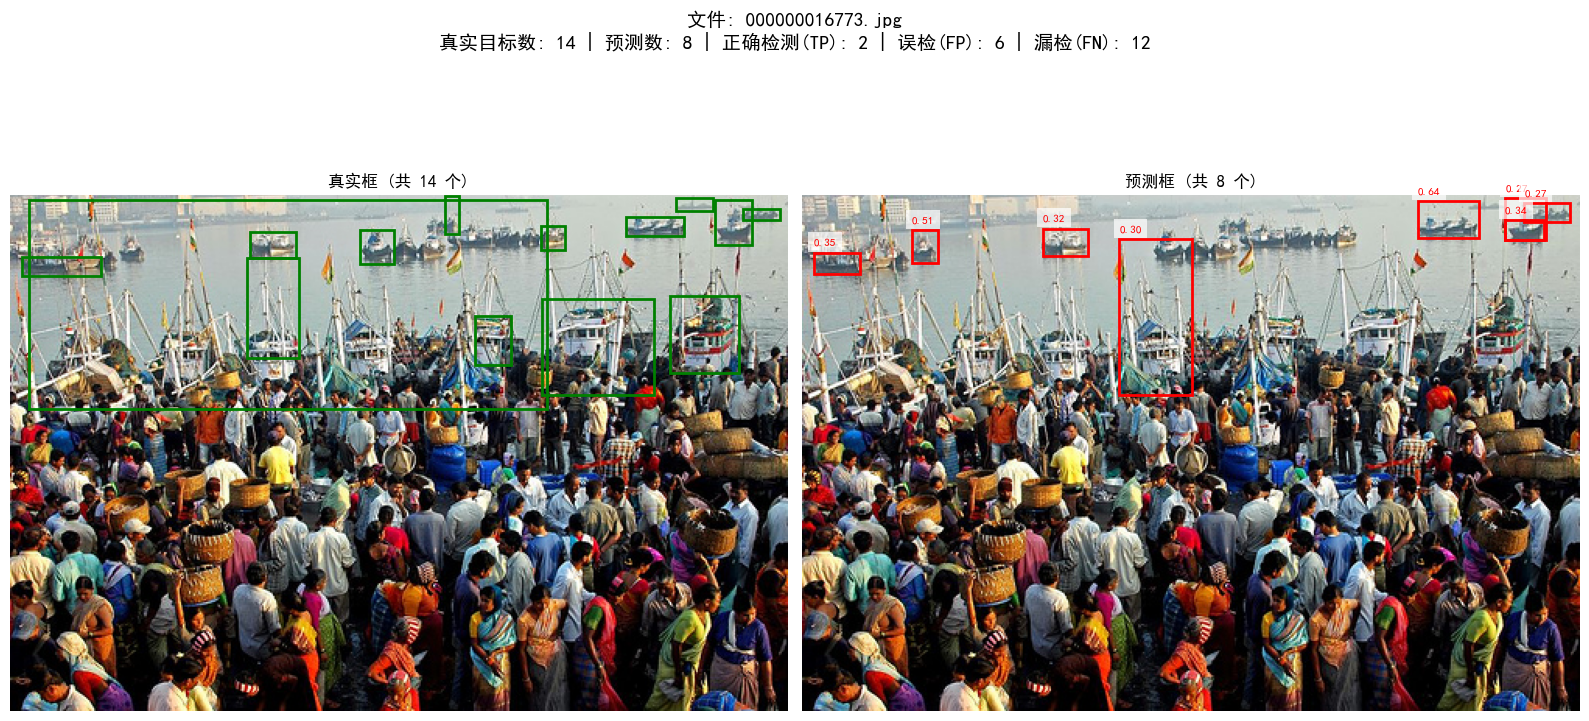


image 1/1 D:\ShipTarget\ship_detection\datasets\seaships\images\test\000000005237.jpg: 288x512 23 ships, 17.3ms
Speed: 1.2ms preprocess, 17.3ms inference, 1.3ms postprocess per image at shape (1, 3, 288, 512)


KeyboardInterrupt: 

In [2]:
# 分析YOLOv11的失败案例
# 定义路径
current_dir = Path.cwd() 
project_root = current_dir / "ship_detection"
dataset_dir = project_root / "datasets" / "seaships"
test_images_dir = dataset_dir / "images" / "test"
test_labels_dir = dataset_dir / "labels" / "test"
results_dir = project_root / "results"

model = YOLO(results_dir / "yolov11" / "baseline512" / "weights" / "best.pt")
model2 = YOLO(results_dir / "improved" / "mmsa_con" / "weights" / "best.pt")
model3 = YOLO(results_dir / "improved" / "mmsa_512" / "weights" / "best.pt")
# 执行错误分析
analysis = analyze_failures(model, test_images_dir, test_labels_dir, conf_threshold=0.25, iou_threshold=0.5, max_images=50)

print(f"总图像数: {analysis['total_images']}")
print(f"真正例 (TP): {analysis['tp']}")
print(f"假正例 (FP): {analysis['fp']}")
print(f"假负例 (FN): {analysis['fn']}")
print(f"精确率: {analysis['precision']:.4f}")
print(f"召回率: {analysis['recall']:.4f}")
print(f"F1分数: {analysis['f1']:.4f}")

# 可视化前几个失败案例
visualize_failures(model, analysis['failures'], test_images_dir,test_labels_dir, num_samples=3,conf_threshold=0.25)